In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Concatenate, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

dataset_path = r"C:\Users\stmos\Desktop\DR_images"

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [10]:
input_layer = Input(shape=(224,224,3))

x = Conv2D(32,(3,3),activation='relu')(input_layer)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64,(3,3),activation='relu')(x)
x = MaxPooling2D(2,2)(x)

cnn_branch = GlobalAveragePooling2D()(x)

In [11]:
mobilenet = MobileNet(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

mobilenet.trainable = False

mobilenet_branch = GlobalAveragePooling2D()(mobilenet.output)

C:\Users\stmos\AppData\Local\Temp\ipykernel_13748\1823038487.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNet(


In [12]:
combined = Concatenate()([cnn_branch, mobilenet_branch])

x = Dense(128, activation='relu')(combined)
x = Dropout(0.5)(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_dw_1 (DepthwiseConv2D)   │ (None, 112, 112, 32)      │             288 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_dw_1_bn                  │ (None, 112, 112, 32)      │             128 │ conv_dw_1[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_dw_1_relu (ReLU)         │ (None, 112, 112, 32)      │               0 │ conv_dw_1_bn[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_pw_1 (Conv2D)            │ (None, 112, 112, 64)      │           2,048 │ conv_dw_1_relu[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_pw_1_bn                  │ (None, 112, 112, 64)      │             256 │ conv_pw_1[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_pw_1_relu (ReLU)         │ (None, 112, 112, 64)      │               0 │ conv_pw_1_bn[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_pad_2 (ZeroPadding2D)    │ (None, 113, 113, 64)      │               0 │ conv_pw_1_relu[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_dw_2 (DepthwiseConv2D)   │ (None, 56, 56, 64)        │             576 │ conv_pad_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_dw_2_bn                  │ (None, 56, 56, 64)        │             256 │ conv_dw_2[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_dw_2_relu (ReLU)         │ (None, 56, 56, 64)        │               0 │ conv_dw_2_bn[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_pw_2 (Conv2D)            │ (None, 56, 56, 128)       │           8,192 │ conv_dw_2_relu[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_pw_2_bn                  │ (None, 56, 56, 128)       │             51

 Total params: 3,388,293 (12.93 MB)

 Trainable params: 159,429 (622.77 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [13]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.6691 - loss: 0.9548 - val_accuracy: 0.6908 - val_loss: 0.7668
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7202 - loss: 0.7729 - val_accuracy: 0.7415 - val_loss: 0.6614
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7213 - loss: 0.7413 - val_accuracy: 0.7319 - val_loss: 0.6838
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.7308 - loss: 0.7115 - val_accuracy: 0.7592 - val_loss: 0.6311
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.7472 - loss: 0.6853 - val_accuracy: 0.7620 - val_loss: 0.6175
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7366 - loss: 0.6953 - val_accuracy: 0.7579 - val_loss: 0.6106
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7448 - loss: 0.6702 - val_accuracy: 0.7579 - val_loss: 0.6059
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7520 - loss: 0.6529 - val_accuracy: 0.7647 - v

In [16]:
mobilenet.trainable = True

for layer in mobilenet.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7591 - loss: 0.6994 - val_accuracy: 0.7852 - val_loss: 0.6117
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.7526 - loss: 0.6849 - val_accuracy: 0.7811 - val_loss: 0.6089
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.7711 - loss: 0.6496 - val_accuracy: 0.7798 - val_loss: 0.6039
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7718 - loss: 0.6123 - val_accuracy: 0.7798 - val_loss: 0.5957
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7660 - loss: 0.6354 - val_accuracy: 0.7921 - val_loss: 0.5795
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.7687 - loss: 0.6206 - val_accuracy: 0.7948 - val_loss: 0.5864
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7738 - loss: 0.6128 - val_accuracy: 0.7866 - val_loss: 0.5937
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.7820 - loss: 0.5691 - val_accuracy: 0.7962 - v

In [17]:
loss, acc = model.evaluate(val_data)
print("Final Hybrid Model Accuracy =", acc*100)

23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 668ms/step - accuracy: 0.8003 - loss: 0.5742
Final Hybrid Model Accuracy = 80.0273597240448


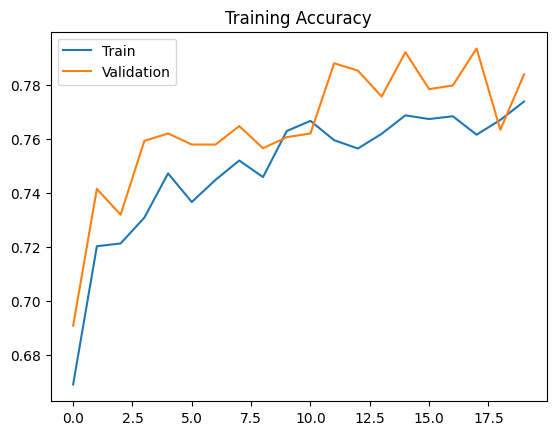

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training Accuracy")
plt.legend(["Train","Validation"])
plt.show()

C:\Users\stmos\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_91']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


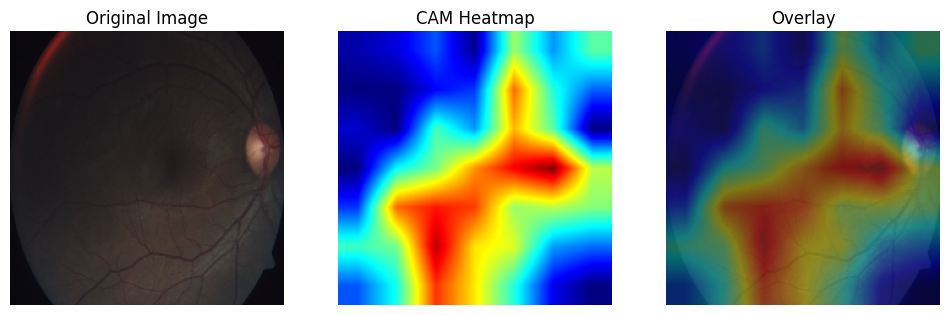

In [19]:
img, label = next(val_data)
image = img[0]

last_conv_layer = mobilenet.get_layer("conv_pw_13_relu")

grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(np.expand_dims(image, axis=0))
    loss = predictions[:, np.argmax(predictions[0])]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

heatmap_display = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_display, cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

overlay = np.uint8(255 * image)
combined = cv2.addWeighted(overlay, 0.6, heatmap_colored, 0.4, 0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_colored)
plt.title("CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(combined)
plt.title("Overlay")
plt.axis("off")

plt.show()


In [20]:
model.save("review3_hybrid_model.keras")